In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline


plt.rcParams['font.family'] = 'Times New Roman,Microsoft YaHei'
plt.rcParams['mathtext.fontset'] = 'stix'  # 设置数学公式字体为stix
from sklearn import preprocessing
import numpy as np
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut
from matplotlib.lines import Line2D



In [2]:
dfmusic = pd.read_pickle("df_chordkey,pkl")
dfbird = pd.read_pickle('final_birds_df.pkl')
dfbasic = pd.read_pickle("soundfeature_other.pkl")
# 去除重复列
dfbasic = dfbasic.loc[:, ~dfbasic.columns.duplicated()]


# 定义高度替换规则
def replace_level(row):
    if row['place'] == 'ZS':
        return '3 m' if row['level'] == 1 else f"{row['level']}m"
    elif row['place'] == 'JH':
        return {1: '1.5 m', 2: '4 m', 3: '8 m', 4: '14 m'}.get(row['level'], f"{row['level']}m")
    elif row['place'] == 'CM':
        return {1: '1.5 m', 2: '10 m', 3: '16 m', 4: '22 m'}.get(row['level'], f"{row['level']}m")
    return f"{row['level']}m"


# 替换 level 列的值
dfbasic['level'] = dfbasic.apply(replace_level, axis=1)
df = pd.merge(dfmusic, dfbird, on=['Date', 'place', 'level'], how='inner')
df = pd.merge(df, dfbasic, on=['Date', 'place', 'level'], how='inner')
# 栖息地分类映射
habitat_mapping = {
    'Aquatic and Wetland Surface Birds': ['Eurasian Wigeon', 'Tundra Swan', 'Mallard',
                                          'Greater White-fronted Goose', 'Common Goldeneye',
                                          'Green-winged Teal', 'Eurasian Coot', 'Eurasian Moorhen'],

    'Shoreline and Marsh Birds': ['Eurasian Curlew', 'Whimbrel'],

    'Grassland Ground Birds': ['Olive-backed Pipit', 'Yellow-browed Bunting', 'Yellow-billed Grosbeak'],

    'Shrub Layer Birds': ['Light-vented Bulbul', 'Chinese Hwamei', 'Japanese Tit',
                          'Silver-throated Tit', 'Chinese Blackbird', 'Pale-legged Leaf Warbler'],

    'Lower Canopy Birds': ['Pale Thrush', 'Oriental Magpie'],

    'Upper Canopy and Aerial Birds': ["Swinhoe's White-eye"]
}

# 将所有物种映射到栖息地类别
species_to_habitat = {}
for habitat, species_list in habitat_mapping.items():
    for species in species_list:
        species_to_habitat[species] = habitat


# 分类函数
def classify_bird_habitat(species):
    return species_to_habitat.get(species, 'Other')  # 若未匹配到则归类为 'Other'


# 应用分类函数
df['habitat'] = df['bird'].copy().apply(classify_bird_habitat)

# 根据分类映射顺序创建分类类型
habitat_order = list(habitat_mapping.keys())
df['habitat'] = pd.Categorical(df['habitat'], categories=habitat_order, ordered=True)
# 定义和弦质量的映射
chord_quality_map = {
    'maj': '',  # major 不需要后缀
    'min': 'm',  # minor 转换为 'm'
    'dim': 'dim',  # diminished 保持不变
    'aug': 'aug',  # augmented 保持不变
    '7': '7',  # dominant 7th
    'maj7': 'maj7',  # major 7th
    'min7': 'm7',  # minor 7th
    'dim7': 'dim7',  # diminished 7th
    'sus4': 'sus4',  # suspended 4th
    'sus2': 'sus2'  # suspended 2nd
}


def convert_chord_name(chord_name):
    if ':' in chord_name:
        root, quality = chord_name.split(':')
        # 使用映射字典转换和弦质量
        return f"{root}{chord_quality_map.get(quality, '')}"
    else:
        return chord_name


# 应用转换函数
df['event'] = df['event'].apply(convert_chord_name)


FileNotFoundError: [Errno 2] No such file or directory: 'df_chordkey,pkl'

In [ ]:
from palettable.tableau import Tableau_20  # 导入 Tableau_20 调色板
import adjustText
tableau_colors = Tableau_20.mpl_colors  # 提取颜色
cmap =plt.cm.colors.ListedColormap(tableau_colors)

# **统计每个鸟类的数量**
bird_counts = df["bird"].dropna().value_counts()

# **按照数量从多到少排序**
sorted_birds = bird_counts.index.tolist()

# **获取唯一鸟类类别及颜色**
unique_birds = sorted_birds
color_map = dict(zip(unique_birds, tableau_colors[:len(unique_birds)]))  # 颜色映射
# **获取所有鸟类**
bird_names = bird_counts.index.tolist()
bird_values = bird_counts.values
# **获取前5种鸟类用于标注**
top5_birds = bird_names[:5]
top5_values = bird_values[:5]
# **所有鸟类的颜色**
color_map = dict(zip(bird_names, tableau_colors[:len(bird_names)]))
bird_colors = [color_map[bird] for bird in bird_names]  # 获取所有颜色

In [2]:
data1 = pd.read_csv('basic_var.csv')
data2 = pd.read_csv('music_var_chordkey.csv')
data3 = pd.read_csv('soundfeature_other.csv')
data = pd.merge(data1, data2, on=['file'], how='left', suffixes=('', '_drop'))
data = data[[col for col in data.columns if not col.endswith('_drop')]]
data = pd.merge(data, data3, on=['file'], how='left', suffixes=('', '_drop'))
data = data[[col for col in data.columns if not col.endswith('_drop')]]
data = data.loc[:, ~data.columns.duplicated()]
data['chord'] = data['chord'].str.strip('{}').str.split(',')
data.rename(columns={'lat': 'latitude', 'lng': 'longitude', 'Unnamed: 0': 'id'}, inplace=True)

In [5]:
data

,id,Date,birdenname,birdspgen,file,realfilename,rec,cnt,loc,latitude,...,EVNspMean,EVNspCount,TFSD,H_Havrda,H_Renyi,H_gamma,H_GiniSimpson,AGI,ROItotal,ROIcover
0,0,2022-01-16 00:00:00,Eurasian Teal,Anas crecca,XC706499.mp3,XC706499,Irish Wildlife Sounds,Ireland,"Tacumshane, Wexford, County Wexford",52.1853,...,0.050250,0.237873,0.000000,0.323276,1.750406,342.933459,0.846384,1.763521,144.0,3.166691
1,1,2023-12-13 10:03:00,Eurasian Teal,Anas crecca,XC872164.mp3,XC872164,Johannes Dag Mayer,Germany,"Suedsee, Laupheim, Biberach, Tübingen, Baden-W...",48.2078,...,0.020933,0.159533,0.478084,0.331455,2.589358,35582.846346,0.942238,1.263552,73.0,3.437754
2,2,2024-11-04 08:11:00,Eurasian Teal,Anas crecca,XC946313.mp3,XC946313,Sonothèque ADVL,France,"Cabane Vauban (Carolles), Manche, Normandie",48.7443,...,0.027326,0.492219,0.364335,0.329500,2.232644,4023.734559,0.916002,1.307255,128.0,9.873588
3,3,2014-07-13 09:00:00,Eurasian Teal,Anas crecca,XC187090.mp3,XC187090,Albert Lastukhin,Russian Federation,"Novocheboksarsk, gorod Novocheboksarsk, Chuvas...",56.1056,...,0.057078,0.361062,0.460048,0.333260,4.210168,24701.050359,0.987338,1.420083,267.0,5.509801
4,4,2023-12-18 15:03:00,Eurasian Teal,Anas crecca,XC872174.mp3,XC872174,Johannes Dag Mayer,Germany,"Suedsee, Laupheim, Biberach, Tübingen, Baden-W...",48.2078,...,0.037341,0.188268,0.476359,0.332782,3.201939,38474.387121,0.972857,1.285792,161.0,4.207794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14620,14620,2020-10-04 21:05:00,Greater White-fronted Goose,Anser albifrons,XC592979.mp3,XC592979,Juha Saari,Finland,"Pihlajamäki, Helsinki, Uusimaa",60.2357,...,0.077633,0.652936,0.000000,0.332714,3.144461,6733.278040,0.967246,2.038239,278.0,13.252572
14621,14621,2022-10-02 22:00:00,Greater White-fronted Goose,Anser albifrons,XC753535.mp3,XC753535,Uku Paal,Estonia,"Tartu, Tartu City, Tartu maakond",58.3752,...,0.044391,0.222631,0.000000,0.332871,3.289931,10339.811767,0.968750,1.265332,397.0,4.669571
14622,14622,2008-02-17 19:05:00,Greater White-fronted Goose,Anser albifrons,XC280889.mp3,XC280889,Peter Boesman,Belgium,"Uitkerkse polders, West-Vlaanderen",51.2950,...,0.081556,2.182158,0.000000,0.330864,2.452579,880.761415,0.924076,4.589344,89.0,4.272296
14623,14623,2021-11-23 01:36:00,Greater White-fronted Goose,Anser albifrons,XC718649.mp3,XC718649,Chèvremont Fabian,Belgium,"Fléron, Liège, Wallonie",50.6041,...,0.046229,0.257331,0.387644,0.331772,2.681686,16106.852922,0.948817,1.245774,110.0,1.291541


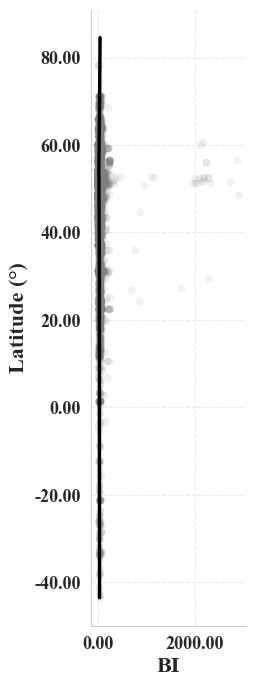

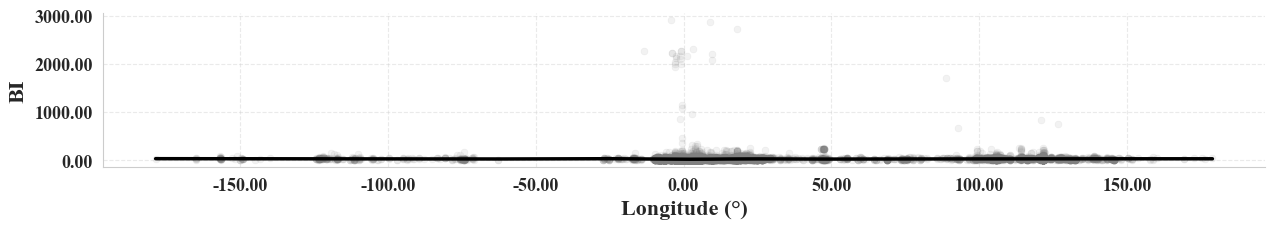

In [21]:
import seaborn as sns
import statsmodels.api as sm

name = 'BI'

VAR=data[name]

# **LOWESS 平滑曲线**
def lowess_smooth(x, y, frac=0.3):
    """局部加权回归（LOWESS）平滑数据"""
    lowess = sm.nonparametric.lowess(y, x, frac=frac)
    return lowess[:, 0], lowess[:, 1]


# **绘制 LEQf vs 纬度**
fig, ax = plt.subplots(figsize=(2, 8))

# 散点图
sns.scatterplot(y=data["latitude"], x=VAR, color="gray", alpha=0.1, s=25, edgecolor=None)



# LOWESS 平滑曲线
lat_sorted, leqf_smooth = lowess_smooth(data["latitude"], VAR)
ax.plot(leqf_smooth, lat_sorted, color="black", linewidth=2.5, label="LOWESS Fit")

# **格式优化**
ax.set_xlabel(name, fontsize=16, fontweight="bold")
ax.set_ylabel("Latitude (°)", fontsize=16, fontweight="bold")
ax.spines["top"].set_visible(False)  # 移除顶部边框
ax.spines["right"].set_visible(False)  # 移除右侧边框
# ax.legend(fontsize=14, loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))  # Y轴格式化显示两位小数
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))  # Y轴格式化显示两位小数
ax.tick_params(axis='both', which='major', labelsize=13, width=1.5)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
# plt.savefig(f"{name}纬度.jpg",dpi=500, bbox_inches='tight')

plt.show()

# **绘制 LEQf vs 经度**
fig, ax = plt.subplots(figsize=(15, 2))
# 散点图
sns.scatterplot(x=data["longitude"], y=VAR, color="gray", alpha=0.1, s=25, edgecolor=None)

# LOWESS 平滑曲线
lon_sorted, leqf_smooth = lowess_smooth(data["longitude"], VAR)
ax.plot(lon_sorted, leqf_smooth, color="black", linewidth=2.5, label="LOWESS Fit")

# **格式优化**
ax.set_xlabel("Longitude (°)", fontsize=16, fontweight="bold")
ax.set_ylabel(name, fontsize=16, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# ax.legend(fontsize=14, loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))  # Y轴格式化显示两位小数
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))  # Y轴格式化显示两位小数
ax.tick_params(axis='both', which='major', labelsize=13, width=1.5)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
# plt.savefig(f"{name}经度.jpg",dpi=500, bbox_inches='tight')

plt.show()